In [233]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

# EDA

In [234]:
#read in data file

data = pd.read_csv('stats.csv')

data.head()

,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,fast_swing_rate,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent
0,"Beck, Jordan",687597,2025,588,16,29.6,7.3,0.319,0.301,73.2,32.9,10.7,36.9,9.6,8.2,38.5,100.308270,94.263086,31.2,47.4
1,"Rojas, Josh",668942,2025,211,2,22.7,9.0,0.232,0.263,67.8,2.5,9.9,30.6,3.5,9.0,36.8,98.368844,93.541469,23.1,46.2
2,"Langeliers, Shea",669127,2025,523,31,19.7,6.9,0.364,0.328,73.8,39.6,11.4,33.4,11.3,8.1,44.9,102.509663,95.562115,25.1,52.4
3,"McCarthy, Jake",664983,2025,222,4,18.0,4.5,0.256,0.286,69.8,7.8,8.4,28.2,5.3,4.7,27.6,96.219722,92.144883,21.1,49.4
4,"Mitchell, Garrett",669003,2025,78,0,32.1,9.0,0.261,0.288,76.1,70.3,10.0,28.9,6.7,6.7,42.2,101.702092,95.238522,30.9,44.9


In [235]:
#rows and columns
data.shape

(588, 20)

In [236]:
#no nulls
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   last_name, first_name  588 non-null    object 
 1   player_id              588 non-null    int64  
 2   year                   588 non-null    int64  
 3   pa                     588 non-null    int64  
 4   home_run               588 non-null    int64  
 5   k_percent              588 non-null    float64
 6   bb_percent             588 non-null    float64
 7   woba                   588 non-null    float64
 8   xwoba                  588 non-null    float64
 9   avg_swing_speed        588 non-null    float64
 10  fast_swing_rate        588 non-null    float64
 11  attack_angle           588 non-null    float64
 12  sweet_spot_percent     588 non-null    float64
 13  barrel_batted_rate     588 non-null    float64
 14  solidcontact_percent   588 non-null    float64
 15  hard_h

In [237]:
data.describe()

,player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,fast_swing_rate,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent
count,588.000000,588.0,588.000000,588.00000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000,588.000000
mean,658896.676871,2025.0,309.537415,9.60034,24.236905,7.981803,0.291685,0.298342,71.489116,22.093878,10.019218,32.960884,8.084694,6.186395,39.593537,99.722831,94.170100,26.520068,48.238265
std,49135.728693,0.0,212.280616,10.07477,7.669638,3.468980,0.053066,0.044472,2.655190,18.566421,3.637064,5.729255,4.668318,2.730923,8.461990,2.538472,1.465887,7.072227,5.284010
min,455117.000000,2025.0,25.000000,0.00000,3.100000,0.000000,0.106000,0.173000,62.600000,0.000000,-4.000000,0.000000,0.000000,0.000000,15.000000,92.342291,90.376606,5.300000,33.300000
25%,650241.250000,2025.0,111.000000,2.00000,19.000000,5.600000,0.264000,0.270000,69.675000,6.475000,7.600000,30.000000,4.500000,4.500000,34.175000,97.934468,93.081090,21.900000,44.700000
50%,669222.500000,2025.0,279.000000,6.00000,23.900000,7.650000,0.297000,0.300500,71.600000,17.350000,10.000000,33.600000,7.650000,6.300000,40.100000,99.729025,94.136792,26.000000,48.050000
75%,682629.750000,2025.0,497.250000,15.00000,28.200000,10.100000,0.328000,0.327000,73.300000,33.650000,12.300000,36.625000,11.100000,7.725000,45.500000,101.409721,95.125113,31.200000,51.800000
max,810938.000000,2025.0,732.000000,60.00000,55.300000,22.200000,0.463000,0.460000,80.600000,97.300000,21.400000,53.300000,26.100000,20.000000,68.800000,107.633614,98.832539,52.700000,69.900000


<module 'matplotlib.pyplot' from '/home/prob9023/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

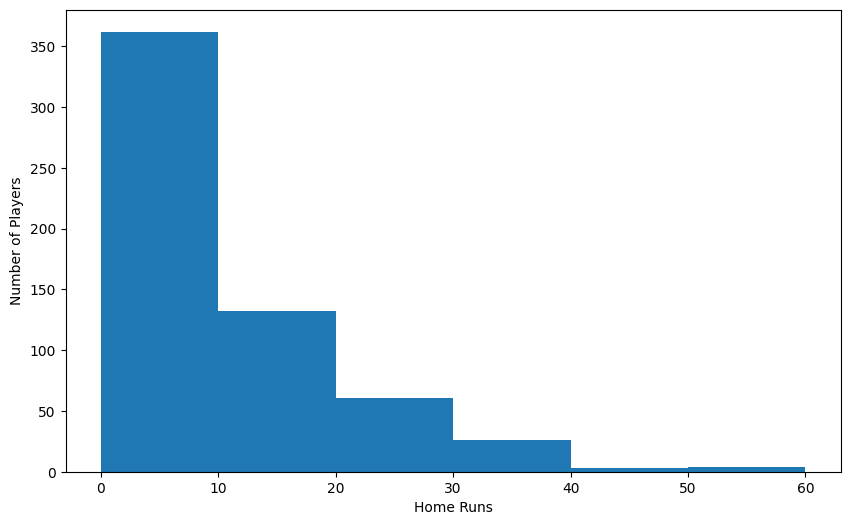

In [238]:
#plot home runs

#create bins with 70 being max
max_hr = max(data['home_run'])
bins = range(0, 70, 10)

#plot
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(data['home_run'], bins=bins)
ax.set_xlabel('Home Runs')
ax.set_ylabel('Number of Players')

plt

<module 'matplotlib.pyplot' from '/home/prob9023/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

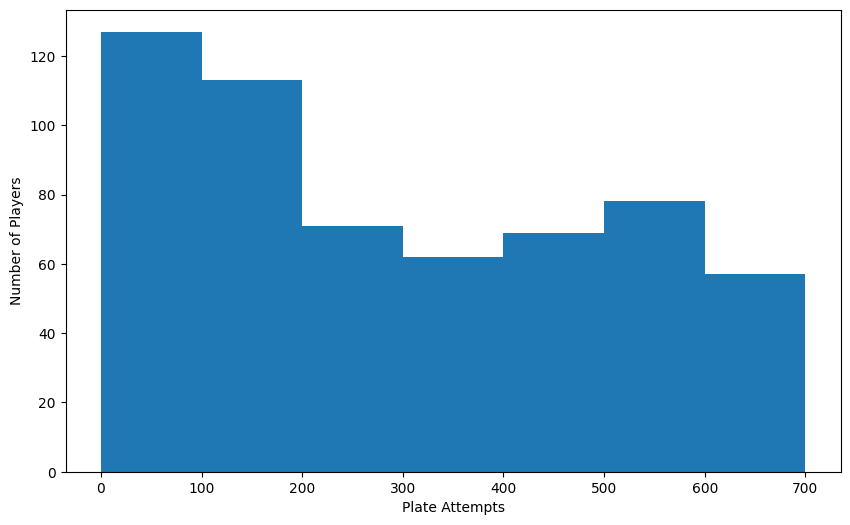

In [240]:
#plot at bats (plate attempts)

max_pa = max(data['pa'])
bins = range(0,((max_pa//100) +1) *100, 100) 

#plot
fig, ax = plt.subplots(figsize=(10,6))

ax.hist(data['pa'], bins=bins)
ax.set_xlabel('Plate Attempts')
ax.set_ylabel('Number of Players')

plt

<module 'matplotlib.pyplot' from '/home/prob9023/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

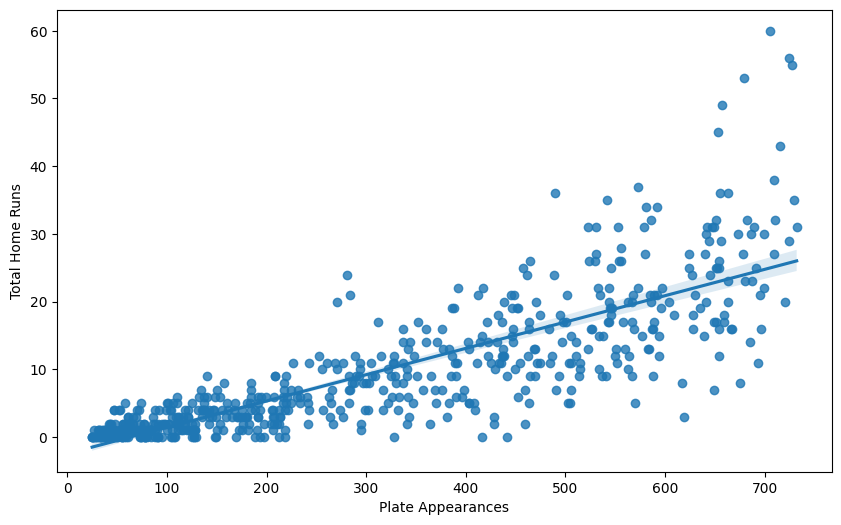

In [241]:
#plot
fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(data=data, x='pa', y='home_run')

ax.set_xlabel('Plate Appearances')
ax.set_ylabel('Total Home Runs')

plt

In [242]:
# if we remove any rows with less than 200 plate attempts how much data would that leave me
(data['pa'] >=200).sum()
#data would go from 588 to 348

np.int64(348)

In [243]:
data_pa = (data[data['pa'] >=200])
data_pa.head()

,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,fast_swing_rate,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent
0,"Beck, Jordan",687597,2025,588,16,29.6,7.3,0.319,0.301,73.2,32.9,10.7,36.9,9.6,8.2,38.5,100.308270,94.263086,31.2,47.4
1,"Rojas, Josh",668942,2025,211,2,22.7,9.0,0.232,0.263,67.8,2.5,9.9,30.6,3.5,9.0,36.8,98.368844,93.541469,23.1,46.2
2,"Langeliers, Shea",669127,2025,523,31,19.7,6.9,0.364,0.328,73.8,39.6,11.4,33.4,11.3,8.1,44.9,102.509663,95.562115,25.1,52.4
3,"McCarthy, Jake",664983,2025,222,4,18.0,4.5,0.256,0.286,69.8,7.8,8.4,28.2,5.3,4.7,27.6,96.219722,92.144883,21.1,49.4
5,"Stephenson, Tyler",663886,2025,342,13,33.9,10.8,0.319,0.313,70.1,4.9,13.3,42.2,14.5,7.0,49.2,100.887213,94.951515,30.6,43.6


In [249]:
#predictors minus name and year and home_runs
#after testing removed woba and xwoba and pa
X = data_pa.drop(columns=['player_id','pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba'])
#target is home runs
y = data_pa['home_run']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

#use defaults for now
rfr = RandomForestRegressor(
    random_state=28,
    n_estimators = 200,
    max_depth = 9
)

#fit model
rfr.fit(X_train, y_train)

#make prediction
y_pred = rfr.predict(X_test)

#check scores
print(rfr.score(X_train, y_train))
print(rfr.score(X_test, y_test))

0.9198999438535325
0.5870618192822666


In [250]:
#looking at feature importance
importance = rfr.feature_importances_
feature_names = X.columns

#create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance}).sort_values(by='importance', ascending=False)

#print results
print(importance_df)

                 feature  importance
6     barrel_batted_rate    0.425752
8       hard_hit_percent    0.149883
0              k_percent    0.091154
10       avg_hyper_speed    0.064226
4           attack_angle    0.062928
9         avg_best_speed    0.033277
1             bb_percent    0.031706
11         whiff_percent    0.027563
7   solidcontact_percent    0.026579
5     sweet_spot_percent    0.024576
12         swing_percent    0.024477
3        fast_swing_rate    0.020604
2        avg_swing_speed    0.017275


In [251]:
#save model to use for 2026 data
with open('2025_model.pkl', 'wb') as file:
    pickle.dump(rfr, file)

In [252]:
#read in 2026 stats as of 5/27 before any games had been played for the day
data2026 = pd.read_csv('stats2026.csv')

data2026.head()

,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,fast_swing_rate,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent
0,"Myers, Dane",667472,2026,88,3,26.1,12.5,0.342,0.379,72.2,23.6,8.4,42.3,12.2,9.6,32.7,99.065663,93.875291,16.5,35.8
1,"Beavers, Dylan",687637,2026,119,2,23.5,11.8,0.317,0.308,71.5,13.8,7.4,33.8,5.2,6.5,39.0,99.306662,93.790126,23.4,44.5
2,"Thomas, Lane",657041,2026,110,1,20.9,18.2,0.299,0.311,71.7,17.5,8.1,39.4,3.0,6.1,34.8,97.235726,92.632244,21.7,40.5
3,"Burger, Jake",669394,2026,207,10,26.6,6.3,0.320,0.309,74.8,51.8,9.1,32.6,10.1,9.4,49.3,102.926652,95.862670,35.8,50.1
4,"Stewart, Sal",701398,2026,231,12,19.5,13.0,0.362,0.378,72.0,24.5,10.8,35.5,16.8,5.8,41.9,101.264636,95.014927,26.2,49.8


In [253]:
#load model
with open('2025_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [254]:
#removing low PA players
bottom25 = np.quantile(data2026['pa'], 0.25)

data2026_pa = (data2026[data2026['pa'] >=bottom25])

#setting X
X_2026 = data2026_pa.drop(columns=['player_id', 'pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba'])

#predict 2026 home runs
data2026_pa['predicted_hrs'] = loaded_model.predict(X_2026)*0.33

/tmp/ipykernel_5331/2113199886.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2026_pa['predicted_hrs'] = loaded_model.predict(X_2026)*0.33


In [255]:
data2026_pa.head()

,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,...,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent,predicted_hrs
0,"Myers, Dane",667472,2026,88,3,26.1,12.5,0.342,0.379,72.2,...,8.4,42.3,12.2,9.6,32.7,99.065663,93.875291,16.5,35.8,5.055047
1,"Beavers, Dylan",687637,2026,119,2,23.5,11.8,0.317,0.308,71.5,...,7.4,33.8,5.2,6.5,39.0,99.306662,93.790126,23.4,44.5,2.392113
2,"Thomas, Lane",657041,2026,110,1,20.9,18.2,0.299,0.311,71.7,...,8.1,39.4,3.0,6.1,34.8,97.235726,92.632244,21.7,40.5,2.105452
3,"Burger, Jake",669394,2026,207,10,26.6,6.3,0.320,0.309,74.8,...,9.1,32.6,10.1,9.4,49.3,102.926652,95.862670,35.8,50.1,5.345052
4,"Stewart, Sal",701398,2026,231,12,19.5,13.0,0.362,0.378,72.0,...,10.8,35.5,16.8,5.8,41.9,101.264636,95.014927,26.2,49.8,8.271238


<module 'matplotlib.pyplot' from '/home/prob9023/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

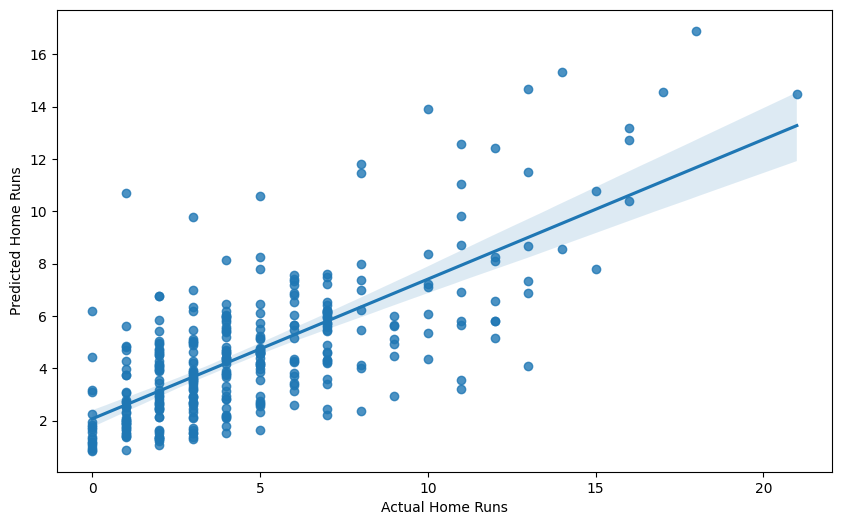

In [257]:
#trend line plot
fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(data=data2026_pa, x='home_run', y='predicted_hrs')

ax.set_xlabel('Actual Home Runs')
ax.set_ylabel('Predicted Home Runs')

plt

In [258]:
#determine how accurate the model is
mean_abs_error = mean_absolute_error(data2026_pa['home_run'], data2026_pa['predicted_hrs'])

r2 = r2_score(data2026_pa['home_run'], data2026_pa['predicted_hrs'])

print(f'Mean Absolute Error: {mean_abs_error:.2f} home runs')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 1.91 home runs
R2 Score: 0.53


## Testing Notes 

### With PA included
- Mean Absolute Error: 3.13 home runs
- R2 Score: -0.13

### Without PA
- Mean Absolute Error: 9.26 home runs
- R2 Score: -8.41

### Multiplying the model by 0.33 to account for on average how much of the 2026 season has been played

- Mean Absolute Error: 2.07 home runs
- R2 Score: 0.42

### PA included, adjusted RFR parameters

- Mean Absolute Error: 3.06 home runs
- R2 Score: -0.09

### PA excluded, adjusted RFR parameters, removed bottom quartile of 2026 data, multiplied by 0.33 to account for season % played

- Mean Absolute Error: 1.91 home runs
- R2 Score: 0.53

### Feature Importance Based on Last Iteration

- barrel_batted_rate    0.425752
- hard_hit_percent    0.149883
- k_percent    0.091154
- avg_hyper_speed    0.064226
- attack_angle    0.062928
- avg_best_speed    0.033277
- bb_percent    0.031706
- whiff_percent    0.027563
- solidcontact_percent    0.026579
- sweet_spot_percent    0.024576
- swing_percent    0.024477
- fast_swing_rate    0.020604
- avg_swing_speed    0.017275

In [259]:
data2026_sorted = data2026_pa.sort_values(by='predicted_hrs', ascending=False)

data2026_sorted.head(10)

,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,...,attack_angle,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent,predicted_hrs
219,"Murakami, Munetaka",808959,2026,230,18,33.0,17.8,0.394,0.372,75.2,...,18.8,28.6,20.5,6.3,58.0,104.745809,97.660480,43.1,41.6,16.899300
43,"Wood, James",695578,2026,259,14,29.3,17.4,0.405,0.431,76.5,...,11.8,40.3,25.4,9.0,60.4,106.799919,99.085723,32.0,37.8,15.328500
232,"Trout, Mike",545361,2026,238,13,23.5,19.7,0.390,0.418,75.2,...,7.7,33.3,20.6,8.3,48.5,103.651774,96.300527,21.6,37.1,14.679842
135,"Judge, Aaron",592450,2026,238,17,28.6,16.0,0.401,0.423,76.1,...,12.6,35.9,22.7,6.3,55.5,105.431221,97.712919,32.9,43.4,14.538920
7,"Schwarber, Kyle",656941,2026,229,21,34.1,14.0,0.416,0.391,77.0,...,14.2,38.3,25.2,6.1,50.4,104.162534,96.714703,33.3,42.5,14.470775
28,"Soto, Juan",665742,2026,159,10,15.1,13.8,0.404,0.416,72.9,...,13.9,29.2,19.6,3.5,50.4,103.178951,96.658732,20.9,41.4,13.922700
200,"Buxton, Byron",621439,2026,208,16,26.0,6.7,0.387,0.338,73.8,...,14.7,33.6,19.7,3.6,46.7,101.469357,95.191831,31.9,53.5,13.168100
98,"Alvarez, Yordan",670541,2026,234,16,16.2,15.0,0.432,0.478,75.9,...,9.1,45.2,17.3,15.9,51.6,105.202362,97.164601,19.3,42.7,12.714123
12,"Raley, Luke",670042,2026,150,11,33.3,5.3,0.387,0.388,75.3,...,16.0,40.9,20.5,3.4,52.3,103.286363,96.176146,43.5,54.4,12.567225
104,"Muncy, Max",571970,2026,190,12,25.8,13.7,0.385,0.403,71.7,...,16.4,35.1,18.4,3.5,51.8,102.763742,95.926875,29.4,44.3,12.431051


In [260]:
#creating a home run rate to account for at bat variance
data_pa['hr_rate'] = (data_pa['home_run']/data_pa['pa'])

#predictors minus name and year and home_runs 
X = data_pa.drop(columns=['player_id','pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba','hr_rate'])
#target is home runs
y = data_pa['hr_rate']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

#use defaults for now
rfr = RandomForestRegressor(
    random_state=28,
    n_estimators = 200,
    max_depth = 9
)

#fit model
rfr.fit(X_train, y_train)

#make prediction
y_pred = rfr.predict(X_test)

#check scores
print(rfr.score(X_train, y_train))
print(rfr.score(X_test, y_test))

/tmp/ipykernel_5331/3084283458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_pa['hr_rate'] = (data_pa['home_run']/data_pa['pa'])


0.9498537101211966
0.6998423619117864


In [261]:
#looking at feature importance
importance = rfr.feature_importances_
feature_names = X.columns

#create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance}).sort_values(by='importance', ascending=False)

#print results
print(importance_df)

                 feature  importance
6     barrel_batted_rate    0.728367
0              k_percent    0.045488
4           attack_angle    0.040267
2        avg_swing_speed    0.024723
3        fast_swing_rate    0.024594
8       hard_hit_percent    0.023219
7   solidcontact_percent    0.019518
11         whiff_percent    0.019253
12         swing_percent    0.018999
5     sweet_spot_percent    0.017607
1             bb_percent    0.015017
10       avg_hyper_speed    0.013854
9         avg_best_speed    0.009094


In [262]:
with open('2025_model.pkl', 'wb') as file:
    pickle.dump(rfr, file)

    #load model
with open('2025_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

#setting X
X_2026 = data2026_pa.drop(columns=['player_id', 'pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba', 'predicted_hrs'])

#predict 2026 home runs
data2026_pa['predicted_hr_rate'] = loaded_model.predict(X_2026)

/tmp/ipykernel_5331/454763093.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2026_pa['predicted_hr_rate'] = loaded_model.predict(X_2026)


In [263]:
data2026_pa['predicted_hrs'] = data2026_pa['pa']*data2026_pa['predicted_hr_rate']

data2026_pa_sorted = data2026_pa.sort_values(by='predicted_hrs', ascending=False)

data2026_pa_sorted.head(10)

/tmp/ipykernel_5331/3689094476.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2026_pa['predicted_hrs'] = data2026_pa['pa']*data2026_pa['predicted_hr_rate']


,"last_name, first_name",player_id,year,pa,home_run,k_percent,bb_percent,woba,xwoba,avg_swing_speed,...,sweet_spot_percent,barrel_batted_rate,solidcontact_percent,hard_hit_percent,avg_best_speed,avg_hyper_speed,whiff_percent,swing_percent,predicted_hrs,predicted_hr_rate
43,"Wood, James",695578,2026,259,14,29.3,17.4,0.405,0.431,76.5,...,40.3,25.4,9.0,60.4,106.799919,99.085723,32.0,37.8,17.904357,0.069129
7,"Schwarber, Kyle",656941,2026,229,21,34.1,14.0,0.416,0.391,77.0,...,38.3,25.2,6.1,50.4,104.162534,96.714703,33.3,42.5,17.643519,0.077046
135,"Judge, Aaron",592450,2026,238,17,28.6,16.0,0.401,0.423,76.1,...,35.9,22.7,6.3,55.5,105.431221,97.712919,32.9,43.4,17.037743,0.071587
219,"Murakami, Munetaka",808959,2026,230,18,33.0,17.8,0.394,0.372,75.2,...,28.6,20.5,6.3,58.0,104.745809,97.660480,43.1,41.6,16.722969,0.072709
232,"Trout, Mike",545361,2026,238,13,23.5,19.7,0.390,0.418,75.2,...,33.3,20.6,8.3,48.5,103.651774,96.300527,21.6,37.1,16.338711,0.068650
200,"Buxton, Byron",621439,2026,208,16,26.0,6.7,0.387,0.338,73.8,...,33.6,19.7,3.6,46.7,101.469357,95.191831,31.9,53.5,14.488523,0.069656
73,"Kurtz, Nick",701762,2026,243,8,28.8,21.4,0.409,0.389,77.9,...,38.7,16.0,10.1,58.0,106.258109,98.410290,36.0,39.8,13.458411,0.055384
294,"Walker, Jordan",691023,2026,218,15,25.7,9.2,0.412,0.383,78.8,...,34.3,16.4,7.1,51.4,105.680186,97.447028,32.1,52.5,12.753210,0.058501
267,"Baldwin, Drake",686948,2026,216,13,20.4,11.1,0.407,0.418,75.0,...,42.1,18.6,11.0,53.8,103.678356,96.840638,23.1,50.4,12.165720,0.056323
122,"Cruz, Oneil",665833,2026,236,11,35.6,7.6,0.338,0.336,78.5,...,31.8,16.9,5.3,61.4,107.077825,99.136637,37.6,45.5,12.094305,0.051247


In [264]:
#determine how accurate the model is
mean_abs_error = mean_absolute_error(data2026_pa['home_run'], data2026_pa['predicted_hrs'])

r2 = r2_score(data2026_pa['home_run'], data2026_pa['predicted_hrs'])

print(f'Mean Absolute Error: {mean_abs_error:.2f} home runs')
print(f'R2 Score: {r2:.2f}')

Mean Absolute Error: 1.50 home runs
R2 Score: 0.71


# Results After Creating HR Rate

Going back and forth on including or not including plate attempts, and how to handle varying 2026 plate attempts in projecting home runs, I decided to use a home run rate to give a fair shot irrespective of plate attempts. This ended up being the best performing model by a long shot with the below numbers signaling a solid success.

- Mean Absolute Error: 1.50 home runs
- R2 Score: 0.71

### Feature Importance

- barrel_batted_rate    0.728367
- k_percent    0.045488
- attack_angle    0.040267
- avg_swing_speed    0.024723
- fast_swing_rate    0.024594
- hard_hit_percent    0.023219
- solidcontact_percent    0.019518
- whiff_percent    0.019253
- swing_percent    0.018999
- sweet_spot_percent    0.017607
- bb_percent    0.015017
- avg_hyper_speed    0.013854
- avg_best_speed    0.009094

<module 'matplotlib.pyplot' from '/home/prob9023/miniconda3/lib/python3.13/site-packages/matplotlib/pyplot.py'>

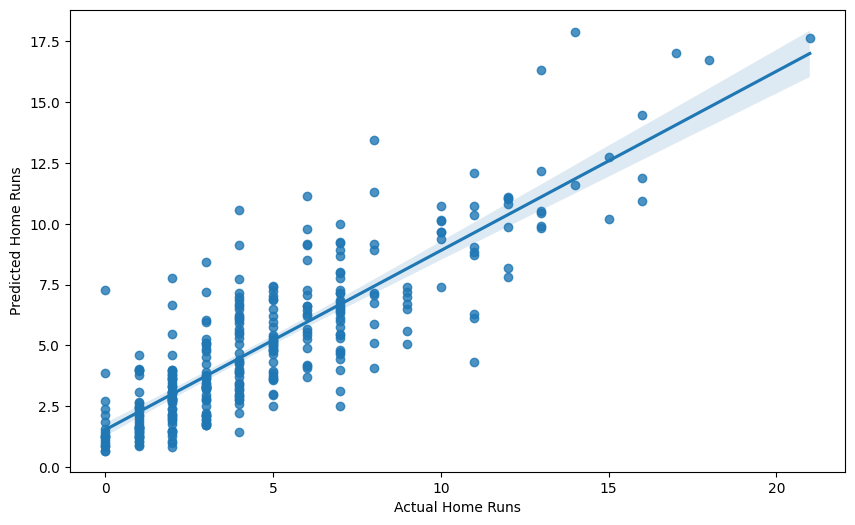

In [270]:
#trend line plot
fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(data=data2026_pa, x='home_run', y='predicted_hrs')

ax.set_xlabel('Actual Home Runs')
ax.set_ylabel('Predicted Home Runs')

plt

In [265]:
#barrel is technically a combination of attack_angle and exit velocity (avg best speed and avg hyper speed) 

#predictors minus name and year and home_runs 
X_ba = data_pa.drop(columns=['player_id','pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba','hr_rate', 'barrel_batted_rate'])
#target is home runs
y_ba = data_pa['hr_rate']

#train test split
X_train, X_test, y_train, y_test = train_test_split(X_ba, y_ba, test_size=0.2, random_state=28)

#use defaults for now
rfr = RandomForestRegressor(
    random_state=28,
    n_estimators = 200,
    max_depth = 9
)

#fit model
rfr.fit(X_train, y_train)

#make prediction
y_pred = rfr.predict(X_test)

#check scores
print(rfr.score(X_train, y_train))
print(rfr.score(X_test, y_test))

0.9268323285715366
0.3841896413872248


In [266]:
#looking at feature importance
importance = rfr.feature_importances_
feature_names = X_ba.columns

#create a dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance}).sort_values(by='importance', ascending=False)

#print results
print(importance_df)

                 feature  importance
9        avg_hyper_speed    0.224667
4           attack_angle    0.203694
7       hard_hit_percent    0.167229
8         avg_best_speed    0.101163
3        fast_swing_rate    0.077525
2        avg_swing_speed    0.049861
0              k_percent    0.036026
1             bb_percent    0.035587
5     sweet_spot_percent    0.030104
10         whiff_percent    0.025328
11         swing_percent    0.024899
6   solidcontact_percent    0.023918


In [267]:
#setting X
X_2026_ba = data2026_pa.drop(columns=['player_id', 'pa', 'home_run','year', 'last_name, first_name','woba', 'xwoba', 'predicted_hrs', 'predicted_hr_rate','barrel_batted_rate'])

#predict 2026 home runs round 2
data2026_pa_ba = data2026_pa.copy()

data2026_pa_ba['predicted_hr_rate'] = rfr.predict(X_2026_ba)

data2026_pa_ba['predicted_hrs'] = data2026_pa_ba['pa']*data2026_pa_ba['predicted_hr_rate']

In [269]:
#determine how accurate the model is
mean_abs_error_ba = mean_absolute_error(data2026_pa_ba['home_run'], data2026_pa_ba['predicted_hrs'])

r2_ba = r2_score(data2026_pa_ba['home_run'], data2026_pa_ba['predicted_hrs'])

print(f'Mean Absolute Error: {mean_abs_error_ba:.2f} home runs')
print(f'R2 Score: {r2_ba:.2f}')

Mean Absolute Error: 1.84 home runs
R2 Score: 0.58


# Results - Removing Barrel Rate

Despite barrel rate being a combination of launch angle and exit velocity, removing it and relying on the raw metrics detracts from the model's performance

- Mean Absolute Error: 1.84 home runs
- R2 Score: 0.58